# 1. Project Setup

In [1]:
import os
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [2]:
# global setting for plots
plt.style.use('seaborn-v0_8-whitegrid')

# set random seed use modern numpy
rng = np.random.default_rng(123)

# initialise TensorBoard writer
log_dir = f'runs/clasical_linear_regression'

# clear previous runs
if os.path.exists(log_dir):
    shutil.rmtree(log_dir) # delete previous runs

# create new directory
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

# set hyperparameters
epochs = 100
num_samples = 1000
num_features = 10

In [3]:
# scikit-learn library
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# statsmodels library
import statsmodels.api as sm

# 2. Linear Regression Equation
$$ \hat{y} = w_{0} + w_{1} \cdot x_{1} + w_{2} \cdot x_{2} + \dots + w_{n} \cdot x_{n} $$

In this equation:
- $\hat{y}$ is the dependent variable or predicted value
- $w_{0}$ is bias term or intercept
- $w_{1}, w_{2}, \dots, w_{n}$ are the coefficients
- $x_{1}, x_{2}, \dots, x_{n}$ are the independent variables or features that use to predict or describe the dependent variable

The equation can be written in matrix form as:
$$ \hat{y} = b + X \cdot W $$

where:
- $\hat{y}$ is the predicted value having shape (num_samples, 1)
- $W$ is the matrix of coefficients including bias term has shape (num_features, 1)
- $X$ is the matrix of features has shape (num_samples, num_features)

*Notes:*
$ \theta \cdot X $ is the dot product of two matrices. use ```np.dot()``` or ```torch.matmul()``` to calculate the dot product.

The shape of $X$ is (num_samples, num_features) and the shape of $W$ is (num_features, 1)

the correct order of dot product is: $X \cdot W$  the final shape is (num_samples, num_features) * (num_features, 1) = (num_samples, 1)

Let's implement the linear regression use scikit-learn library.

# 3. Linear Regression with Scikit-learn

In [4]:
# === data generation step ===
# generate features matrix
X = rng.normal(loc=0, scale=1, size=(num_samples, num_features)) # normal random in [0, 1) include 0 but exclude

# generate coefficients matrix
W = rng.normal(loc=0, scale=1, size=(num_features, 1))

# set true relation between X and y
y_true = 3 + 6 * np.dot(X, W) # y = 3 + 9 * X * W

# adding noise
err = rng.normal(loc=0, scale=0.5, size=(num_samples, 1)) # normal noise in [0, 1) include 0 but exclude

# add noise to the true relation
y_noise = y_true + err

# === modeling step ===
lin_reg = LinearRegression(fit_intercept=True, n_jobs=-1) # init linear regression class, njob=-1 use all cores
lin_reg.fit(X, y_noise) # fit model to the data
y_scikit_pred = lin_reg.predict(X) # predict the y values


print(f'the model is:')
print(f'y = {lin_reg.intercept_} + {lin_reg.coef_} * X')
print(f'R^2 = {lin_reg.score(X, y_noise):.2f}') # R^2 score
print(f'Model parameters: {lin_reg.get_params()}') # model parameters

the model is:
y = [2.98429196] + [[ -2.83969572  -9.98113286   1.3706796    0.17586869  -0.20436118
   10.7528651   -8.56381197   9.20048429  10.03510615 -15.78734212]] * X
R^2 = 1.00
Model parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False}


# 4. Linear Regression use Statmodels

In [5]:
# === statsmodels step ===
# add intercept to the model matrix
X_intercept = sm.add_constant(X) # add intercept to the model matrix, as statsmodels does not add intercept by default

# fit the model
ols_model = sm.OLS(y_noise, X_intercept).fit() # use the first column of y_noise
y_ols_pred = ols_model.predict(X_intercept) # predict the y values

print(ols_model.summary()) # print the summary of the model

# log summary to TensorBoard
ols_summary_str = ols_model.summary().as_text() # get the summary of the model
writer.add_text('OLS summary', f'<pre>{ols_summary_str}</pre>') # use <pre> tag to preserve the format
writer.flush() # flush the writer

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.808e+05
Date:                Sun, 30 Mar 2025   Prob (F-statistic):               0.00
Time:                        12:29:41   Log-Likelihood:                -735.95
No. Observations:                1000   AIC:                             1494.
Df Residuals:                     989   BIC:                             1548.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9843      0.016    183.390      0.0

In [6]:
# === plotting step ===
if X.shape[1] == 1:
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(X, y_noise, 'b.')

    # plot true relationship
    ax.plot(X, y_true, 'g-', label=f'True: = 2 + 4 * X', alpha=0.5)

    # plot predicted relationship
    ax.plot(X, y_scikit_pred, 'r-', label=f'Prediction:')

    ax.plot(X, y_ols_pred, 'm-', label=f'OLS:')

    # add legend
    ax.set_title('Linear Regression')
    ax.set_xlabel('X')
    ax.set_ylabel(f'y = y_true + err') # use raw string to render latex
    ax.legend()
    plt.show()
    writer.add_figure('1.linear_regression', fig, global_step=0) # add figure to TensorBoard
    writer.flush() # flush the writer
else:
    print(f'X has {X.shape[1]} features, cannot plot')

X has 10 features, cannot plot


# 5. Understand Model Diagnosis Plots

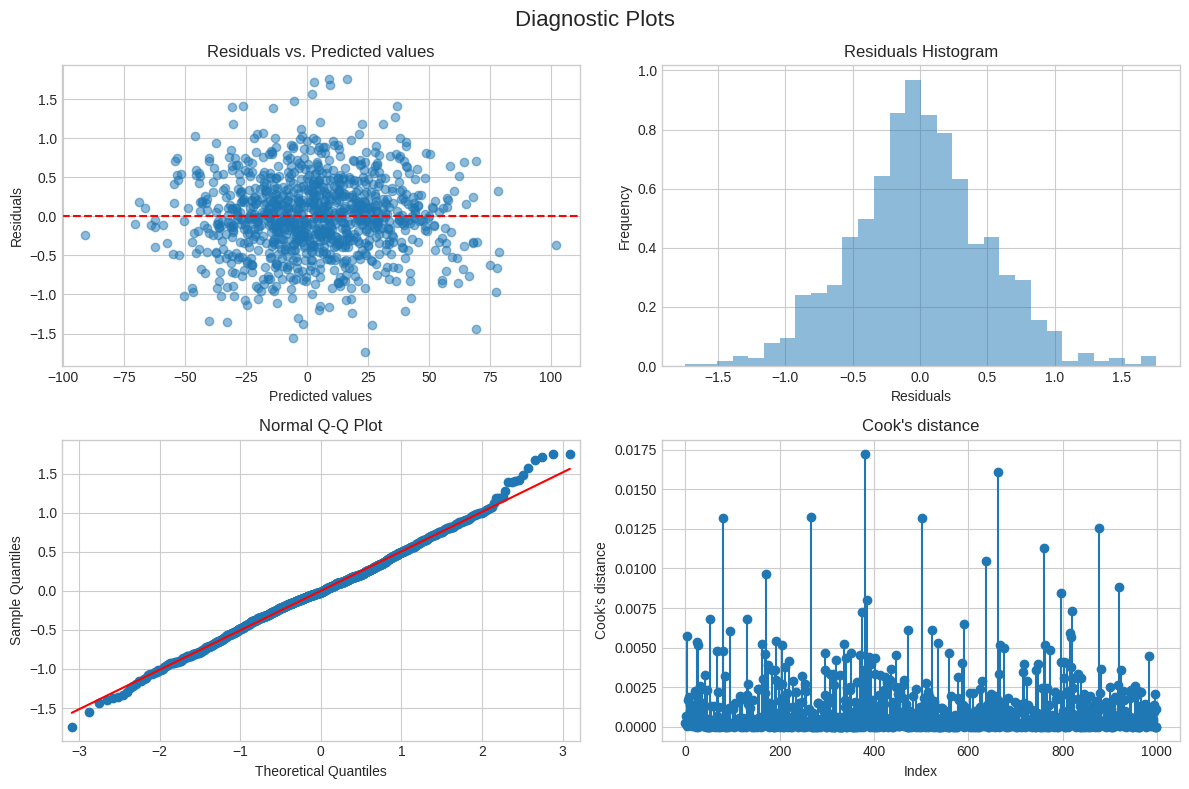

In [7]:
# === diagnostic step ===
# plot the residuals vs. predicted values
residuals = (y_noise - y_scikit_pred).flatten() # flatten the residuals to 1D array
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# residuals vs. predicted values
axes[0].scatter(y_scikit_pred, residuals, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Predicted values')

# residuals histogram
axes[1].hist(residuals, bins=30, density=True, alpha=0.5)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Histogram')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[2])
axes[2].set_title('Normal Q-Q Plot')

# cook's distance
cooks_d = ols_model.get_influence().cooks_distance[0]
axes[3].stem(cooks_d, linefmt='-', markerfmt='o', basefmt=' ')
axes[3].set_xlabel('Index')
axes[3].set_ylabel("Cook's distance")
axes[3].set_title("Cook's distance")

# set the title for the entire figure
fig.suptitle('Diagnostic Plots', fontsize=16)
plt.tight_layout()
plt.show()

# log the figure to TensorBoard
writer.add_figure('2.diagnostic_plots/4-plots', fig, global_step=0) # add figure to TensorBoard
writer.flush() # flush the writer

## 5.1 Residuals vs Predicted Values
This plot shows if residuals have non-linear patterns. The x-axis presents the predicted values and the y-axis presents the residual values. The red line presents the mean zero of rediduals. As can be seen, the residuals are randomly scattered around the red line. This indicates that the model is a good fit for the data.

## 5.2. Residuals Histogram
This plot shows the distribution of residuals. The x-axis presents the residual values and the y-axis presents the frequency of residuals. As can be seen, the residuals are normally distributed. This indicates that the model is a good fit for the data.

## 5.3. Q-Q Plot or Quantile-Quantile Plot
This is a plot is use to visually check whether sample data from a specific data distribution or not. a Q-Q plot order the sample data from smallest to largest, then plot these values against the expected values from a specific distribution. The above plot uses normal distribution as expected distribution. The quantile values of the input sample appears a long the -axis, and the quantile values of the expected distribution appear a long the x-axis, theoretical quantiles. The red line is standardised line, the expected order statistics are scaled by the standard deviation of the given sample and have the mean added to them.

If sample data is taken from expected distribution, the point will fall along the red line. The above plot is used to check whether residuals are from normal distribution or not. The plot indicates that the residuals are from normal distribution.

## 5.4. Cook's Distance
Defination: Cook’s distance is the scaled change in fitted values, which is useful for identifying outliers in the X values (observations for predictor variables). Cook’s distance shows the influence of each observation on the fitted response values. An observation with Cook’s distance larger than three times the mean Cook’s distance might be an outlier [MathWorks](https://au.mathworks.com/help/stats/cooks-distance.html)

Cook's distance is a algebraically defined as:
$$
D_i = \frac{r_i^2}{p \cdot MSE} \cdot \frac{h_ii}{(1 - h_ii)^2}
$$
where:
- $D_i$ is the Cook's distance for observation $i$
- $r_i$ is the residual for observation $i$
- $p$ is the number of predictors (including intercept)
- $MSE$ is the mean square error
- $h_ii$ is the leverage for observation $i$

Leverage value for each data point is extracted as the diagonal of the hat matrix $H$, which is defined as:
$$
H = X(X^TX)^{-1}X^T
$$

where:
- $X$ is the design matrix (matrix of predictors, including intercept).
- The leverage values are always between 0 and 1.
- Rule of thumb is that:
    - Leverage values greater than $2p/n$ are considered high leverage points, where $p$ is the number of predictors and $n$ is the number of observations.
    - An observation with Cook's distance three times higher than the mean Cook's distance might be an outlier [Ref](https://au.mathworks.com/help/stats/cooks-distance.html)

Let's manually compute the Cook's distance.

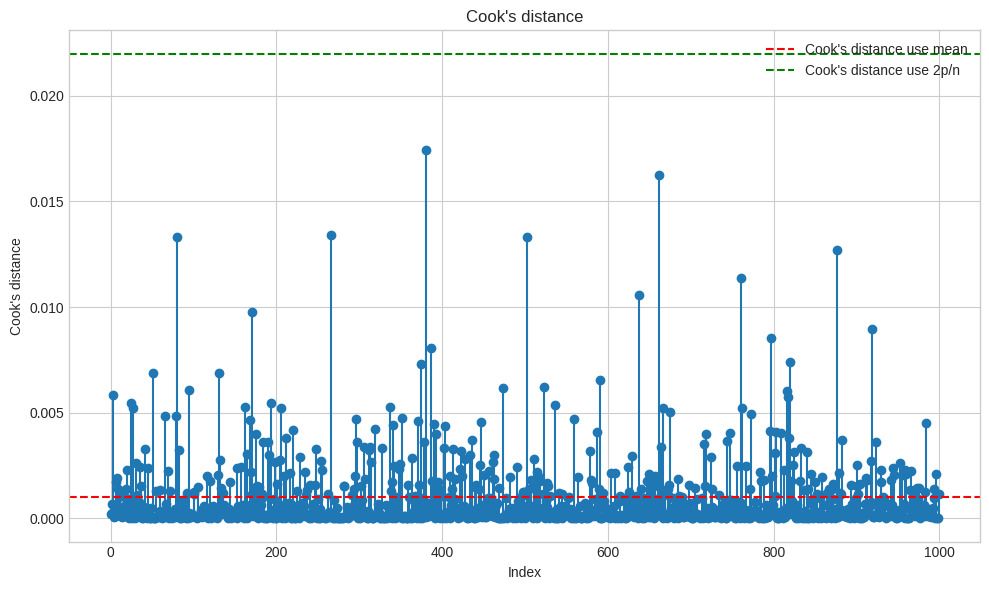

In [8]:
# === compute mean squared error ===
mse = mean_squared_error(y_noise, y_scikit_pred)

X_scitkit_intercept = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1) # add intercept to the model matrix

# compute H matrix
H = X_scitkit_intercept @ np.linalg.inv(X_scitkit_intercept.T @ X_scitkit_intercept) @ X_scitkit_intercept.T

# compute leverage
leverage = np.diag(H) # leverage is the diagonal of H matrix, has shape (num_samples)

# compute cook's distance
# Ensure residuals have the correct shape by flatten
cooks_scikit_d = (residuals**2 / (X_scitkit_intercept.shape[1] * mse)) * (leverage / (1 - leverage)**2)


# plot cook's distance
fig, ax = plt.subplots(figsize=(10, 6))
ax.stem(cooks_scikit_d, linefmt='-', markerfmt='o', basefmt=' ')

ax.axhline(y = np.mean(cooks_scikit_d), color='red', linestyle='--', label=f"Cook's distance use mean")
ax.axhline(y = 2*X_scitkit_intercept.shape[1] / X_scitkit_intercept.shape[0], color='green', linestyle='--', label=f"Cook's distance use 2p/n")

ax.set_xlabel('Index')
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's distance")

plt.legend()
plt.tight_layout()
plt.show()

# log the figure to TensorBoard
writer.add_figure('2.diagnostic_plots/cook-distance', fig, global_step=0) # add figure to TensorBoard
writer.flush() # flush the writer

In [9]:
writer.close() # close the writer